# Decision Trees: Tuning and Evaluation (Regression)

In this notebook, please try to **mirror the workflow** from the tutorial notebook from last week, but applies it to the new dataset (`amazon_products.csv`).

**Goal:** predict the numeric target **`sales`** using a **Decision Tree Regressor**, including:

- data cleaning + feature engineering
- one-hot encoding for categorical variables
- train/test split
- baseline decision tree model
- 5-fold cross-validation
- hyperparameter tuning with `GridSearchCV` (optional)
- final evaluation on a hold-out test set (optional)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Load the dataset
df = pd.read_csv("amazon_products_副本5.csv")

df.info()
display(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42675 entries, 0 to 42674
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   product_title         42675 non-null  object 
 1   product_rating        41651 non-null  float64
 2   total_reviews         41651 non-null  float64
 3   sales                 32164 non-null  float64
 4   discounted_price      40613 non-null  float64
 5   original_price        40613 non-null  float64
 6   is_best_seller        42675 non-null  object 
 7   is_sponsored          42675 non-null  object 
 8   has_coupon            42675 non-null  object 
 9   buy_box_availability  28022 non-null  object 
 10  delivery_date         30692 non-null  object 
 11  sustainability_tags   3408 non-null   object 
 12  data_collected_at     42675 non-null  object 
 13  product_category      42675 non-null  object 
 14  discount_percentage   40613 non-null  float64
dtypes: float64(6), obje

,product_title,product_rating,total_reviews,sales,discounted_price,original_price,is_best_seller,is_sponsored,has_coupon,buy_box_availability,delivery_date,sustainability_tags,data_collected_at,product_category,discount_percentage
0,BOYA BOYALINK 2 Wireless Lavalier Microphone f...,4.6,375.0,300.0,89.68,159.00,No Badge,Sponsored,Save 15% with coupon,Add to cart,1/9/2025,Carbon impact,21/8/2025 11:14,Phones,43.60
1,"LISEN USB C to Lightning Cable, 240W 4 in 1 Ch...",4.3,2457.0,6000.0,9.99,15.99,No Badge,Sponsored,No Coupon,Add to cart,29/8/2025,NaN,21/8/2025 11:14,Laptops,37.52
2,"DJI Mic 2 (2 TX + 1 RX + Charging Case), Wirel...",4.6,3044.0,2000.0,314.00,349.00,No Badge,Sponsored,No Coupon,Add to cart,1/9/2025,NaN,21/8/2025 11:14,Laptops,10.03
3,"Apple AirPods Pro 2 Wireless Earbuds, Active N...",4.6,35882.0,10000.0,162.24,162.24,Best Seller,Organic,No Coupon,NaN,NaN,NaN,21/8/2025 11:14,Phones,0.00
4,Apple AirTag 4 Pack. Keep Track of and find Yo...,4.8,28988.0,10000.0,72.74,72.74,No Badge,Organic,No Coupon,NaN,NaN,NaN,21/8/2025 11:14,Phones,0.00


## 2. Data processing and exploration

Original shape: (42675, 15)
After dropping missing target: (32164, 15)


,sales
count,32164.000000
mean,1293.665278
std,6318.323574
min,50.000000
25%,100.000000
50%,200.000000
75%,400.000000
max,100000.000000


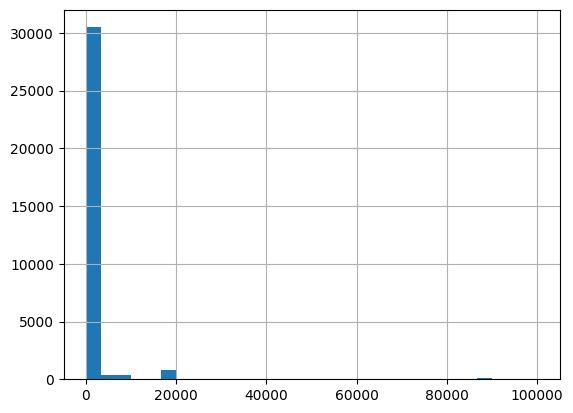

In [3]:
# Drop rows where the target is missing (we cannot train without labels)
print("Original shape:", df.shape)
df = df.dropna(subset=["sales"]).copy()
print("After dropping missing target:", df.shape)

# Quick look at the target distribution
# Hint: use .describe() and .hist()

display(df["sales"].describe())
df["sales"].hist(bins=30)
plt.show()

### 2.1. Feature engineering and cleaning

We do a few **simple transformations** :

- 1. Convert date columns to `datetime` and create `days_to_delivery` (Optional)
- 2. Create a couple of simple text-based features from `product_title` (Optional)
- 3. Parse coupon strings into one-hot coding
- 4. Fill in missing values in prices and discounts
- 5. Handle other missing values and string columns


In [4]:
# --- 1) Convert date columns to datetime and create days_to_delivery ---
df["data_collected_at_dt"] = pd.to_datetime(df["data_collected_at"], errors="coerce")
df["delivery_date_dt"] = pd.to_datetime(df["delivery_date"], errors="coerce")

# Days from collection time to delivery date (NaN if delivery date missing)
df["days_to_delivery"] = (df["delivery_date_dt"] - df["data_collected_at_dt"]).dt.days

# Extract some calendar info from delivery date (NaN if missing; filled later)
df["delivery_month"] = df["delivery_date_dt"].dt.month
df["delivery_weekday"] = df["delivery_date_dt"].dt.weekday  # Monday=0 ... Sunday=6


/tmp/ipython-input-824945089.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["data_collected_at_dt"] = pd.to_datetime(df["data_collected_at"], errors="coerce")


In [5]:
# --- 2) Create a couple of simple text-based features from product_title ---
df["title_word_count"] = df["product_title"].astype(str).str.split().str.len()

In [6]:
# --- 3) Parse coupon strings (the has_coupon column) into one-hot coding ---
# Fill in missing values with "No Coupon", to make NaNs consistent
df["has_coupon"] = df["has_coupon"].fillna("No Coupon").astype(str).str.strip()

# One-hot encode coupon type into multiple dummy columns, merge the dummies back to your df
# Hint: use pd.get_dummies and pd.concat
coupon_dummies = pd.get_dummies(df["has_coupon"], dtype=int)
df = pd.concat([df, coupon_dummies], axis=1)

# drop the original text column
df = df.drop(columns=["has_coupon"])


In [7]:
# --- 4) Fill in missing values in prices and discounts ---

# Make sure price columns are numeric
for col in ["original_price", "discounted_price", "discount_percentage"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Fill in missing values in original_price with the average product price
df["original_price"].fillna(df["original_price"].mean(), inplace=True)

# Fill in missing vaues in discounted_price with the corresponding original_price
# Hint: use np.where()
df["discounted_price"] = np.where(df["discounted_price"].isna(), df["original_price"], df["discounted_price"])

# Recompute discount_percentage if missing (now both original and discounted prices exist)
df["discount_percentage"] = 1 - df["discounted_price"] / df["original_price"]


/tmp/ipython-input-2685727082.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["original_price"].fillna(df["original_price"].mean(), inplace=True)


In [8]:
# --- 5) Handle other missing values and string columns ---
# is_sponsored now is a string column, map it to dummy coding
# Hint: using .map()
df["is_sponsored"] = df["is_sponsored"].map({"Sponsored": 1, "Organic": 0}).astype(int)

# fill missing values in buy_box_availability and sustainability_tags
df["buy_box_availability"].fillna("Unknown", inplace=True)
df["sustainability_tags"].fillna("No", inplace=True)


/tmp/ipython-input-1869691140.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["buy_box_availability"].fillna("Unknown", inplace=True)
/tmp/ipython-input-1869691140.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [9]:

# Summarize all features to keep
all_cols = ['product_rating', 'total_reviews', 'sales', 'discounted_price', 'original_price', 'is_best_seller', 'is_sponsored', 'buy_box_availability',
 'sustainability_tags', 'product_category', 'discount_percentage', 'days_to_delivery', 'delivery_month', 'delivery_weekday',
 'title_word_count']
coupon_cols = [c for c in df.columns if "coupon" in c.lower()]
all_cols.extend(coupon_cols) # add coupon columns to feature list

# Define our target variable and attributes
X = df[all_cols].copy().drop('sales', axis=1)
y = df["sales"]

# one-hot encode all other object columns automatically
X = pd.get_dummies(X, drop_first=False)

# fill any remaining NaNs (trees in sklearn can't take NaNs)
X = X.fillna(X.median(numeric_only=True))

print(X.shape)
X.head()


(32164, 89)


,product_rating,total_reviews,discounted_price,original_price,is_sponsored,discount_percentage,days_to_delivery,delivery_month,delivery_weekday,title_word_count,...,product_category_Networking,product_category_Other Electronics,product_category_Phones,product_category_Power & Batteries,product_category_Printers & Scanners,product_category_Smart Home,product_category_Speakers,product_category_Storage,product_category_TV & Display,product_category_Wearables
0,4.6,375.0,89.68,159.00,1,0.435975,-225.0,1.0,3.0,30,...,False,False,True,False,False,False,False,False,False,False
1,4.3,2457.0,9.99,15.99,1,0.375235,-144.0,4.0,3.0,34,...,False,False,False,False,False,False,False,False,False,False
2,4.6,3044.0,314.00,349.00,1,0.100287,-225.0,1.0,3.0,29,...,False,False,False,False,False,False,False,False,False,False
3,4.6,35882.0,162.24,162.24,0,0.000000,-144.0,4.0,3.0,24,...,False,False,True,False,False,False,False,False,False,False
4,4.8,28988.0,72.74,72.74,0,0.000000,-144.0,4.0,3.0,24,...,False,False,True,False,False,False,False,False,False,False


## 3. Model training preparation

### 3.1. Train/test split
We keep a hold-out test set for the final evaluation (same idea as the tutorial).


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (25731, 89)  Test shape: (6433, 89)


### 3.2. Regression evaluation function

For regression we use:

- **MAE** (mean absolute error)
- **RMSE** (root mean squared error)
- **R²** (coefficient of determination)


In [12]:
def evaluate_regressor(y_true, y_pred, title):
    """
    Evaluate a regression model by comparing predictions against ground-truth targets.

    Parameters
    ----------
    y_true : array-like
        Ground-truth (observed) target values. This is required because all metrics
        (MAE, RMSE, R^2) are defined based on the deviation between predictions and
        true outcomes.
    y_pred : array-like
        Predicted target values generated by the regression model. This is required
        because the function quantifies prediction error and goodness-of-fit by
        comparing these values to `y_true`. Must have the same length/order as `y_true`.
    title : str
        A label used only for display in the printed output. This is useful when
        evaluating multiple models or datasets (e.g., train vs. test) so the metrics
        are clearly attributed in logs.

    Returns
    -------
    dict
        A dictionary containing the computed evaluation metrics:
        - "mae": float, mean absolute error (average absolute deviation).
        - "rmse": float, root mean squared error (penalizes larger errors more).
        - "r2": float, R-squared (proportion of variance explained; can be negative).

    Notes
    -----
    This function prints formatted metric values for quick inspection and also returns
    the raw metric values for programmatic use (e.g., logging, saving, or comparisons).
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"=== {title} ===")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R^2 :", round(r2, 4))

    return {"mae": mae, "rmse": rmse, "r2": r2}


## 4. Baseline decision tree regressor

=== Baseline decision tree (test set) ===
MAE : 300.0461
RMSE: 2315.3252
R^2 : 0.8369


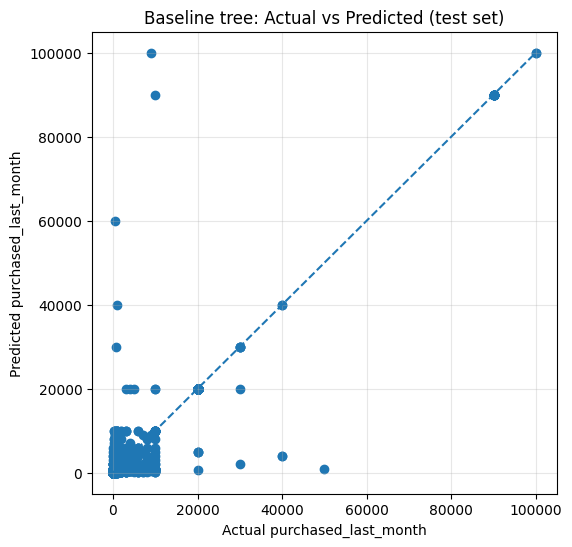

In [13]:
baseline_tree = DecisionTreeRegressor(random_state=42)
baseline_tree.fit(X_train, y_train)

y_pred_test = baseline_tree.predict(X_test)
baseline_metrics = evaluate_regressor(y_test, y_pred_test, title="Baseline decision tree (test set)")

# Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Baseline tree: Actual vs Predicted (test set)")
plt.xlabel("Actual purchased_last_month")
plt.ylabel("Predicted purchased_last_month")
plt.grid(True, alpha=0.3)
plt.show()


## 5. 5-Fold cross-validation (baseline model)

We estimate performance stability using **5-fold CV** on the full dataset.


In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_validate(
    baseline_tree,
    X, y,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    return_train_score=False
)

summary = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R^2"],
    "mean": [
        -np.mean(cv_scores["test_mae"]),
        -np.mean(cv_scores["test_rmse"]),
        np.mean(cv_scores["test_r2"])
    ],
    "std": [
        np.std(-cv_scores["test_mae"]),
        np.std(-cv_scores["test_rmse"]),
        np.std(cv_scores["test_r2"])
    ]
})

display(summary)


,metric,mean,std
0,MAE,347.345164,34.994777
1,RMSE,2534.268288,406.687798
2,R^2,0.835266,0.047023


## 6. Hyperparameter tuning

### 6.1. (Optional) One-parameter sweep: `max_leaf_nodes`

We sweep `max_leaf_nodes` and compare **train vs test RMSE** to visualize under/overfitting.


In [ ]:
max_leaf_nodes_grid = list(range(2, 101, 2))  # keep it moderate for runtime

records = []

for mln in max_leaf_nodes_grid:
    tree = DecisionTreeRegressor(
        random_state=42,
        max_leaf_nodes=mln
    )
    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    nodes = tree.tree_.node_count

    records.append({
        "max_leaf_nodes": mln,
        "nodes": nodes,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse
    })

curve_df = pd.DataFrame(records).sort_values("nodes")
display(curve_df.head())
print("Node range:", (curve_df["nodes"].min(), curve_df["nodes"].max()))


,max_leaf_nodes,nodes,train_rmse,test_rmse
0,2,3,5425.164023,5034.067230
1,4,7,3735.027262,3585.714980
2,6,11,2806.022747,2578.663901
3,8,15,2557.211735,2366.803694
4,10,19,2410.909049,2220.621664


Node range: (3, 199)


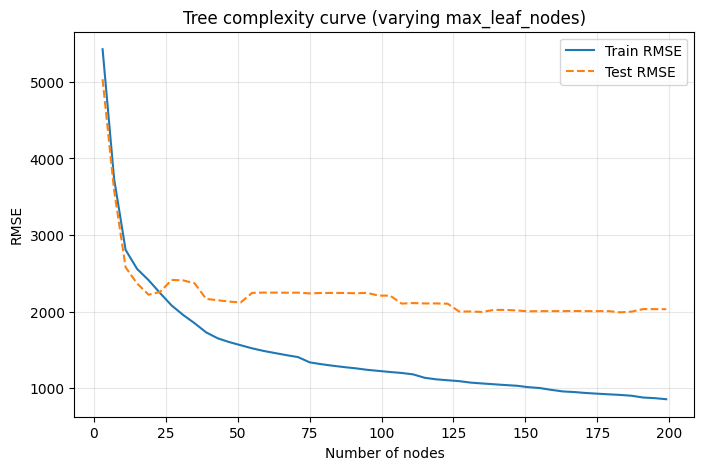

Lowest test RMSE in this sweep:


,max_leaf_nodes,nodes,train_rmse,test_rmse
45,92.0,183.0,912.501307,1990.616974


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(curve_df["nodes"], curve_df["train_rmse"], label="Train RMSE")
plt.plot(curve_df["nodes"], curve_df["test_rmse"], linestyle="--", label="Test RMSE")
plt.xlabel("Number of nodes")
plt.ylabel("RMSE")
plt.title("Tree complexity curve (varying max_leaf_nodes)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_row = curve_df.loc[curve_df["test_rmse"].idxmin()]
print("Lowest test RMSE in this sweep:")
display(best_row.to_frame().T)


### 6.2. GridSearchCV (5-fold) on the training set

Like the tutorial notebook, we tune multiple hyperparameters using 5-fold CV **only on the training set**,
then evaluate the best model once on the hold-out test set.


In [ ]:
# Define a hyperparameter grid to search
param_grid = {
    "max_depth": [None, 3, 5, 8],
    "min_samples_leaf": [1, 5, 10],
    "min_samples_split": [2, 10],
    "max_leaf_nodes": [None, 20, 50]
}

# Define which metrics to compute during CV
scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }

# Set up grid search with 5-fold CV, choose best model by rmse

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),  # model to tune
    param_grid=param_grid,                                        # parameter combinations
    scoring=scoring,                                              # metrics to compute
    refit="rmse",                                              # choose best model by rmse
    cv=cv,                                                        # 5-fold CV splitter
    n_jobs=-1,                                                    # use all CPU cores if possible
    return_train_score=True                                       # also store training scores
)



In [ ]:
# run the grid search on the training set
# show best hyperparameters and best CV score
# Write your code below
grid.fit(X_train, y_train)  # run the grid search on the training set

print("Best parameters:", grid.best_params_)
print("Best CV RMSE:", round(-grid.best_score_, 4))


Best parameters: {'max_depth': 8, 'max_leaf_nodes': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV RMSE: 2571.5667


## 7. Final evaluation on the hold-out test set with your best tree

[  100.71055508 20000.           261.85870479 ...   261.85870479
   100.71055508   820.92568449]
=== Tuned decision tree (test set) ===
MAE : 379.6998
RMSE: 2220.2459
R^2 : 0.85
{'mae': 379.6998008409544, 'rmse': np.float64(2220.2459144680665), 'r2': 0.8500436990988682}


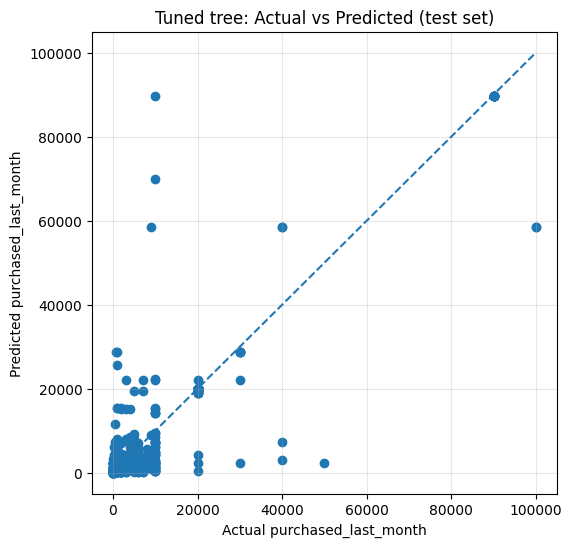

In [ ]:
# extract best model from grid
best_tree = grid.best_estimator_
# Obtain predicted labels on test set
y_pred_test = best_tree.predict(X_test)
print(y_pred_test)
# Evaluate using the function "evaluate_regressor" we defined earlier
best_metrics = evaluate_regressor(y_test, y_pred_test, title="Tuned decision tree (test set)")
print(best_metrics)

# Plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Tuned tree: Actual vs Predicted (test set)")
plt.xlabel("Actual purchased_last_month")
plt.ylabel("Predicted purchased_last_month")
plt.grid(True, alpha=0.3)
plt.show()


## 8. Cross-validation performance of the best model

In [ ]:
# Locate the cross validation and CV performance summary code snippets from the baseline tree section above

cv_scores_best = cross_validate(
    best_tree,
    X, y,
    cv=cv,
    scoring = scoring,
    return_train_score=False
)

summary_best = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R^2"],
    "mean": [
        -np.mean(cv_scores_best["test_mae"]),
        -np.mean(cv_scores_best["test_rmse"]),
        np.mean(cv_scores_best["test_r2"])
    ],
    "std": [
        np.std(-cv_scores_best["test_mae"]),
        np.std(-cv_scores_best["test_rmse"]),
        np.std(cv_scores_best["test_r2"])
    ]
})

display(summary_best)


,metric,mean,std
0,MAE,395.877659,18.563459
1,RMSE,2344.681854,122.190180
2,R^2,0.860412,0.017165


## 9. Feature importance (interpreting the tuned tree)

Decision trees provide a simple **feature importance** score.  
This is a quick way to see what the model is using most heavily.


,importance
total_reviews,8.436535e-01
product_category_Power & Batteries,8.127196e-02
is_best_seller_Best Seller,1.823081e-02
discount_percentage,1.743244e-02
original_price,1.601547e-02
title_word_count,1.303880e-02
discounted_price,3.191861e-03
product_category_Other Electronics,2.289932e-03
delivery_month,1.480783e-03
product_category_Laptops,9.142694e-04


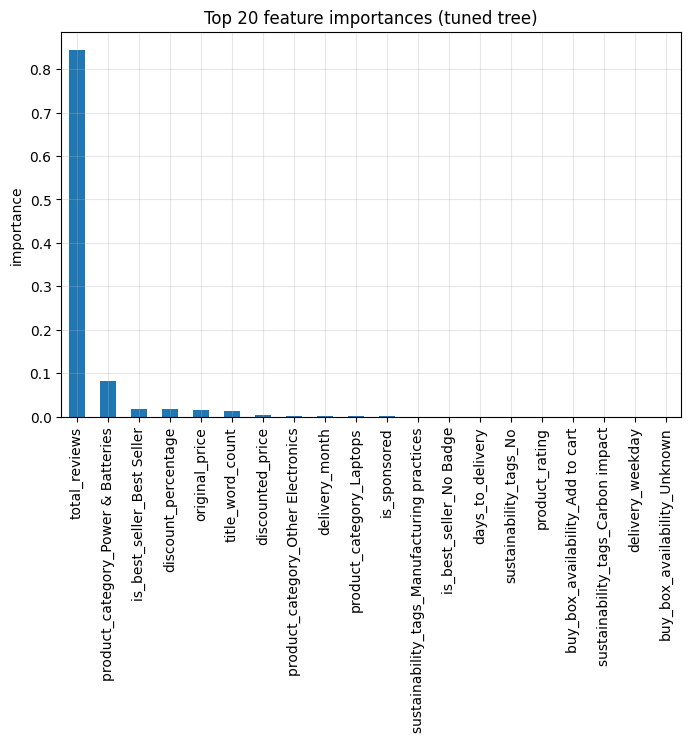

In [ ]:
importances = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False)

display(importances.head(20).to_frame("importance"))

plt.figure(figsize=(8, 5))
importances.head(20).plot(kind="bar")
plt.title("Top 20 feature importances (tuned tree)")
plt.ylabel("importance")
plt.grid(True, alpha=0.3)
plt.show()
